Title: demand_tst_grid.ipynb

Purpose: This script is to test if it is also possible to create a demand per gridcell with a similar outcome to the overall demand

Author: Onno Nennecke on 04.03.2025 Modified: 17.03.2025

#### Load packages

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
# Load cdo package for regridding
from cdo import Cdo
cdo = Cdo()

In [ ]:
# Import code from vdW Paper
import Functions.demand as demand

import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

##### Load population data from vdW Paper

In [3]:
demand_fit_values = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/demand_fit_values.nc')
demand_population_t2m_grid = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid.nc')
# demand_population_t2m_grid_weights = xr.open_dataset('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid_weights.nc')

In [4]:
# Define a rough area for Germany
n = 55.5
s = 47
w = 5.5
e = 15.5

demand_population_t2m_grid_de = demand_population_t2m_grid.sel( dict(country = 9, lat=slice(n,s), lon=slice(w,e)))['population']
# demand_population_t2m_grid_weights_de = demand_population_t2m_grid_weights.sel( dict(country = 9, lat=slice(n,s), lon=slice(w,e)))['population']

In [12]:
population_grid_CIESIN = '/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_t2m_grid.nc'
# Determine directory for regridding
population_regrid_CIESIN = '/climca/people/onennecke/population_data/population_regrid.nc'

# Take the data from population_t2m_grid and regrid it to the same grid as the capacity data (and save it to population_regrid.nc)
cdo.remapsum(
    '/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic_fixed.nc',
    input=population_grid_CIESIN,
    output=population_regrid_CIESIN,
    readCdf=True,
    options="-f nc",
)

'/climca/people/onennecke/population_data/population_regrid.nc'

In [13]:
population_regrid_CIESIN = xr.open_dataset(population_regrid_CIESIN)

In [15]:
population_regrid_CIESIN_slice = population_regrid_CIESIN.sel(dict(lat=slice(s,n), lon=slice(w, e), country=9))['population']
# population_regrid_ISIMIP_slice = population_regrid_ISIMIP.sel(dict(lat=slice(s,n), lon=slice(w, e)))['total-population']


In [16]:
population_regrid_CIESIN_slice
# population_regrid_ISIMIP_slice
print(np.nansum(population_regrid_CIESIN_slice.values) / 1000000)
# print(np.nansum(population_regrid_ISIMIP_slice.values) / 1000000)

78.18941650702027


#### Calculate weights

In [17]:
population_regrid_CIESIN_slice_weights = population_regrid_CIESIN_slice / np.nansum(population_regrid_CIESIN_slice.values)

# Save weights
population_regrid_CIESIN_slice_weights.to_netcdf('/home/onennecke/EU-renewable-energy-modelling-framework/input_files/demand_fit/population_regrid_weights.nc')

# population_regrid_ISIMIP_slice_weights = population_regrid_ISIMIP_slice / np.nansum(population_regrid_ISIMIP_slice.values)

---------------------------------------------------

#### Calculate weighted sum

In [18]:
# demand_list = []
# for y in np.unique(tas["time.year"].values):
#     # print(y)
#     ds_demand0 = xr.Dataset()
#     ds_demand0['temp'] = (tas.sel(time=str(y)) * population_regrid_CIESIN_slice_weights).sum(dim=['lat', 'lon'])
#     demand_list.append(ds_demand0)
    
# ds_demand = xr.concat(demand_list, dim="time") 


weighted_temp_list = []
for y in np.unique(tas["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (tas.sel(time=str(y)) * population_regrid_CIESIN_slice_weights).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 
 

NameError: name 'tas' is not defined

#### Calculate demand

In [23]:
ds_demand_actual = demand.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'weekday'))

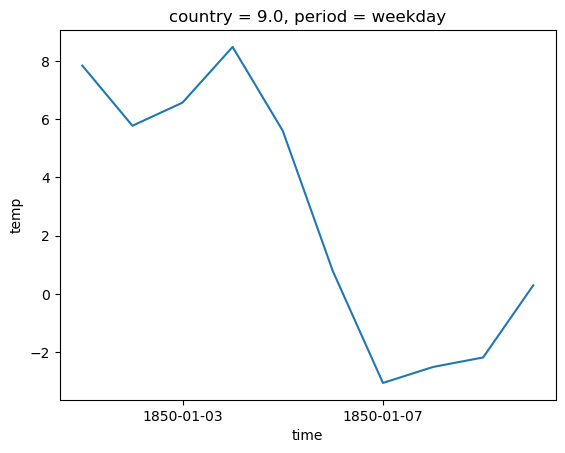

In [24]:
ds_demand_actual['temp'][0:10].plot()

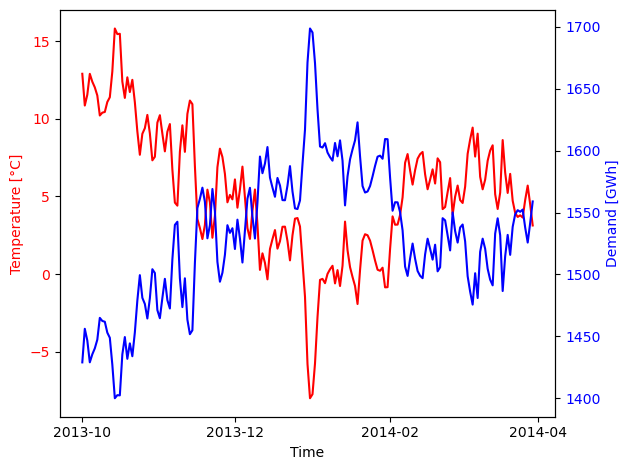

In [26]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots()

a = 191 + 365 * 81
b = 7 + 365 * 82

# Plot temperature on the first y-axis
ax1.plot(ds_weighted_temp['time'][a:b], ds_weighted_temp['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(ds_demand_actual['time'][a:b], ds_demand_actual['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()
plt.show()

---

#### Try demand per cell??

In [19]:
LSTRmodel(tas, demand_fit_values.sel(country = 9, period = 'weekday'), population_regrid_CIESIN_slice_weights)

<xarray.DataArray (time: 30031, lat: 9, lon: 8)> Size: 17MB
dask.array<add, shape=(30031, 9, 8), dtype=float64, chunksize=(1, 9, 8), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 72B 47.59 48.53 49.48 50.42 ... 53.25 54.19 55.13
  * lon      (lon) float64 64B 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
    country  int64 8B 9
    period   <U7 28B 'weekday'

In [38]:
import attributes as attributes
def LSTRmodel(temp, v, weights):
    """
    calculates energy demand based on fit variables and (population weighted) temperature

    parameters
    ----------
    temp (xarray.DataArray): array with temperature data.
        dimemensions: (country, period, time)
    v (xarray.Set): dataset with dataarrays with variables a-f for with same dimensions as temp
        dimensions: (country, period)

    returns
    -------
    demand (xarray.DataArray)
    """
    G = 1 / (1 + np.exp(-v.e * (temp - v.f)))
    demand = (v.a + v.b * temp) * (1 - G) + (v.c + v.d * temp * weights) * G
    return demand


def compute_demand(ds, ds_fitvalues, weights, varin="tas", varout="demand"):
    """
    computes demand based on temperature.
    Constraints demand by maximum heating/cooling capacity based on historic entsoe demand data

    parameters
    ----------
    ds (xarray.DataSet): array with temperature data.
        dimemensions: (country, period, time)
    ds_fitvalues (xarray.DataSet): dataset with dataarrays with variables a-f and max cooling/heating
        for dimensions as temp. dimensions: (country, period)

    returns
    -------
    ds (xarray.DataSet) with demand array
    """
    ds[varout] = LSTRmodel(ds[varin], ds_fitvalues, weights)
    # bound by highest heating and cooling capacities
    ds[varout] = xr.where(
        (ds[varout] > ds_fitvalues.heating_max) & (ds[varin] < ds_fitvalues.f),
        ds_fitvalues.heating_max,
        ds[varout],
    )
    ds[varout] = xr.where(
        (ds[varout] > ds_fitvalues.cooling_max) & (ds[varin] > ds_fitvalues.f),
        ds_fitvalues.cooling_max,
        ds[varout],
    )
    ds = attributes.set_demand_attributes(ds)
    return ds

In [ ]:
'''
# Load climate data
ESM = 'CESM2' 
run = 'r1i1p1f1' # r10i1p1f1  r11i1p1f1  r1i1p1f1  r2i1p1f1  r3i1p1f1  r4i1p1f1  r5i1p1f1  r6i1p1f1  r7i1p1f1  r8i1p1f1  r9i1p1f1

# create list of variables
variables = ['sfcWind', 'rsds', 'tas'] # Surface Wind Speed, Downward Short-Wave Radiation, Air Temperature, Maximum Air Temperature # , 'tas_max'

# Load data
for variable in variables:
    nc = xr.open_mfdataset(f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_historical_{run}_gn_*')
    # select variable
    globals()[variable] = nc[variable] 
    # filter winter
    globals()[variable] = globals()[variable][np.isin(globals()[variable].time.dt.month, [10,11,12,1,2,3]),:,:]
    # select region
    globals()[variable] = globals()[variable].sel(dict(lat=slice(45,60), lon=slice(5,15))) # At the moment roughly germany
    
if tas.units == 'K':
    tas.attrs['units']= '°C'
    tas = tas - 273.15
'''

/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), n

In [ ]:
# Load climate data
ESM = 'CESM2' 
run = 'r1i1p1f1'

# create list of variables
variables = ['sfcWind', 'rsds', 'tas']  # Surface Wind Speed, Downward Short-Wave Radiation, Air Temperature

# Dictionary to store datasets
datasets = {}

# Preprocess function to apply spatial filter directly at load time
def preprocess(ds):
    return ds.sel(lat=slice(45, 60), lon=slice(5, 15))

# Load data
for variable in variables:
    path = f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/historical/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_historical_{run}_gn_*'
    
    # Open with preprocessing
    nc = xr.open_mfdataset(path, preprocess=preprocess)

    # Keep only the desired variable, but as Dataset (not DataArray)
    nc = nc[[variable]]

    # Filter for winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

    # Store in dictionary
    datasets[variable] = nc


/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/xarray/conventions.py:189: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), n

<xarray.Dataset> Size: 18MB
Dimensions:  (time: 30031, lat: 16, lon: 9)
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Data variables:
    tas      (time, lat, lon) float32 17MB dask.array<chunksize=(1, 16, 9), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T21:58:41Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CES

In [66]:
datasets['tas']

<xarray.Dataset> Size: 18MB
Dimensions:  (time: 30031, lat: 16, lon: 9)
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
Data variables:
    tas      (time, lat, lon) float32 17MB dask.array<chunksize=(1, 16, 9), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T21:58:41Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

In [ ]:
weighted_temp_list = []
for y in np.unique(tas["time.year"].values):
    # print(y)
    ds_weigh_temp_0 = xr.Dataset()
    ds_weigh_temp_0['temp'] = (tas.sel(time=str(y)) * population_regrid_CIESIN_slice_weights['population']).sum(dim=['lat', 'lon'])
    weighted_temp_list.append(ds_weigh_temp_0)
    
ds_weighted_temp = xr.concat(weighted_temp_list, dim="time")
 

#### Calculate demand

In [67]:
ds_demand_actual_tst = compute_demand(datasets['tas'], demand_fit_values.sel(country = 9, period = 'weekday'), population_regrid_CIESIN_slice_weights)

In [68]:
ds_demand_actual_tst

<xarray.Dataset> Size: 52MB
Dimensions:  (lat: 16, lon: 9, time: 30031)
Coordinates:
  * lat      (lat) float64 128B 45.71 46.65 47.59 48.53 ... 57.96 58.9 59.84
  * lon      (lon) float64 72B 5.0 6.25 7.5 8.75 10.0 11.25 12.5 13.75 15.0
  * time     (time) object 240kB 1850-01-01 00:00:00 ... 2015-01-01 00:00:00
    country  int64 8B 9
    period   <U7 28B 'weekday'
Data variables:
    tas      (time, lat, lon) float32 17MB dask.array<chunksize=(1, 16, 9), meta=np.ndarray>
    demand   (time, lat, lon) float64 35MB dask.array<chunksize=(1, 9, 9), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    case_id:                15
    cesm_casename:          b.e21.BHIST.f09_g17.CMIP6-historical.001
    contact:                cesm_cmip6@ucar.edu
    creation_date:          2019-01-16T21:58:41Z
    ...                     ...
    sub_experiment:         none
    sub_experiment_id:      none
    branch_time_in_parent:  219000.0
    branch_time_in_child:   674885.0
    branch_method:          standard
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.NCAR.CESM2.h...

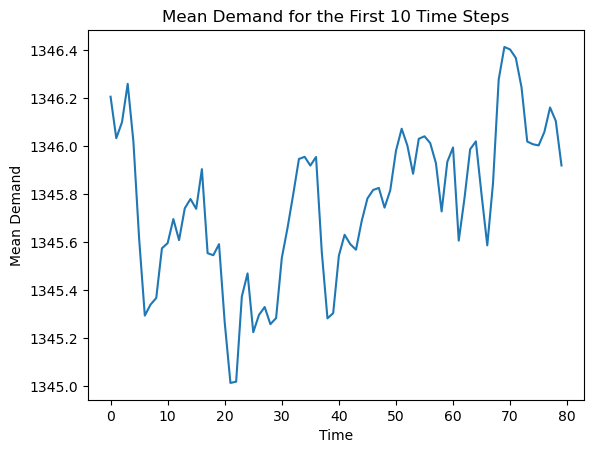

In [87]:
import matplotlib.pyplot as plt

mean_demand = list(range(80))

# Calculate the mean demand for the first 10 time steps
for i in range(80):
    mean_demand[i] = np.nanmean(ds_demand_actual_tst.isel(time=i)['demand'].values)

# mean_demand = np.nanmean(ds_demand_actual_tst.isel(time=slice(0, 10))['demand'].values)

# Plot the mean demand
plt.plot(mean_demand)
plt.xlabel('Time')
plt.ylabel('Mean Demand')
plt.title('Mean Demand for the First 10 Time Steps')
plt.show()

In [ ]:
ds_demand_list = []
for y in np.unique(tas["time.year"].values):
    # print(y)
    ds_demand_0 = xr.Dataset()
    ds_demand_0['temp'] = (tas.sel(time=str(y)) * population_regrid_CIESIN_slice_weights['population']).sum(dim=['lat', 'lon'])
    ds_demand_list.append(ds_demand_0)
    
ds_demand_list = xr.concat(weighted_temp_list, dim="time")